# Импорт библиотек

In [136]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Код из 3 лабы

In [137]:
path = r"F:\\VSCODE_PROJECT\\ML_Proga\\LAB_3\\smartphone_battery_processed.csv"
df = pd.read_csv(path)
target = "Battery_Drop_Per_Hour"
cols_to_keep = [
    "App_Running",
    "Screen_On_Time_min",
    "CPU_Usage_%",
    "Battery_Temperature_C",
    target,
    "Network_Type",
    "Brightness_Level_%",
    "RAM_Usage_MB",
    "Charging_State",
    "Usage_Mode",
    "Intensity",
    "High_Temperature",
]
df = df[cols_to_keep]
X = df.drop(columns=[target])
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
cat_cols = ["App_Running", "Network_Type", "Charging_State", "Usage_Mode"]
num_cols = ["Screen_On_Time_min", "Battery_Temperature_C", "Intensity", "High_Temperature"]
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False).fit(X_train[cat_cols])
scaler = StandardScaler().fit(X_train[num_cols])
def transform_data(data):
    cat = pd.DataFrame(ohe.transform(data[cat_cols]), columns=ohe.get_feature_names_out(), index=data.index)
    num = pd.DataFrame(scaler.transform(data[num_cols]), columns=num_cols, index=data.index)
    return pd.concat([num, cat], axis=1)
X_train_f = transform_data(X_train)
X_test_f = transform_data(X_test)

# Вывод корреляций 

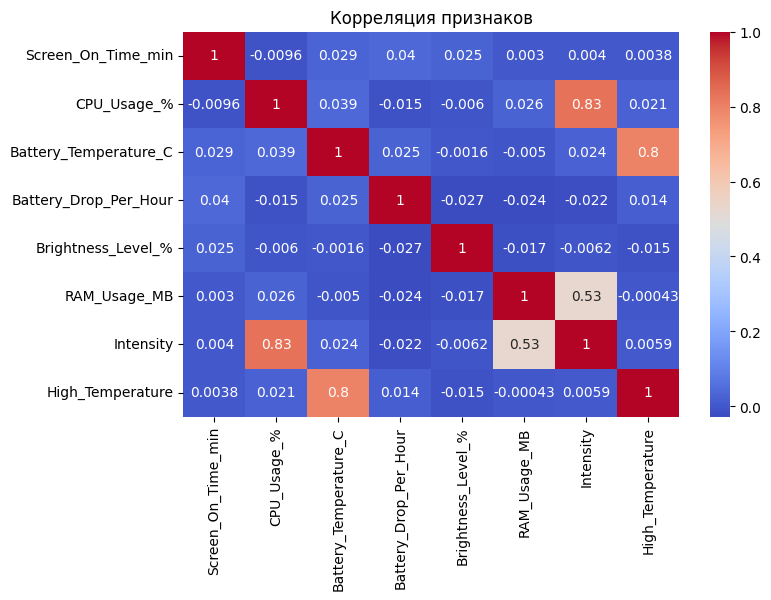

In [138]:
plt.figure(figsize=(8, 5))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap="coolwarm")
plt.title("Корреляция признаков")
plt.show()

# Лабораторная номер 4

Фукнция для записи результатов

In [139]:
results = []
def log_result(name, params, model):
    pred = model.predict(X_test_f)
    results.append({
        "Model": name,
        "Params": params,
        "R2": r2_score(y_test, pred),
        "MSE": mean_squared_error(y_test, pred),
        "MAE": mean_absolute_error(y_test, pred)
    })

Линейная регресия

In [140]:
lr_model = LinearRegression().fit(X_train_f, y_train)
log_result("Linear Regression", "", lr_model)

Рандом форест

In [141]:
# v1: Небольшое количество деревьев и малая глубина (проверка на недообучение)
# v2: Оптимальный баланс - 100 деревьев при средней глубине
# v3: Большая глубина и  большое количество деревьев (проверка на переобучение)
rf_sets = [
    {"n_estimators": 100, "max_depth": 10},
    {"n_estimators": 50, "max_depth": 5},
    {"n_estimators": 200, "max_depth": 20}
]
for i, params in enumerate(rf_sets):
    rf = RandomForestRegressor(**params, random_state=42).fit(X_train_f, y_train)
    log_result(f"Random Forest v{i+1}", str(params), rf)

XG буст

In [142]:
xgb_sets = [
    {"n_estimators": 100, "learning_rate": 0.01},
    {"n_estimators": 200, "learning_rate": 0.01},
    {"n_estimators": 300, "learning_rate": 0.01},
    {"n_estimators": 100, "learning_rate": 0.1},
    {"n_estimators": 100, "learning_rate": 0.2}
]
for i, params in enumerate(xgb_sets):
    xgb = XGBRegressor(**params, random_state=42).fit(X_train_f, y_train)
    log_result(f"XGBoost v{i+1}", str(params), xgb)

# Вывод результатов моделей

In [143]:
print(pd.DataFrame(results).sort_values(by="R2", ascending=False).to_string(index=False))

            Model                                       Params        R2       MSE      MAE
 Random Forest v1       {'n_estimators': 100, 'max_depth': 10} -0.005832 24.865608 4.000737
 Random Forest v2         {'n_estimators': 50, 'max_depth': 5} -0.007862 24.915801 4.005426
       XGBoost v1 {'n_estimators': 100, 'learning_rate': 0.01} -0.009883 24.965764 4.011270
       XGBoost v2 {'n_estimators': 200, 'learning_rate': 0.01} -0.020577 25.230141 4.028617
Linear Regression                                              -0.020677 25.232613 4.031622
       XGBoost v3 {'n_estimators': 300, 'learning_rate': 0.01} -0.025110 25.342208 4.041257
 Random Forest v3       {'n_estimators': 200, 'max_depth': 20} -0.030266 25.469662 4.065086
       XGBoost v4  {'n_estimators': 100, 'learning_rate': 0.1} -0.105972 27.341231 4.229718
       XGBoost v5  {'n_estimators': 100, 'learning_rate': 0.2} -0.211954 29.961240 4.389227


# Топ 10 важных признаков для рандом фореста V1

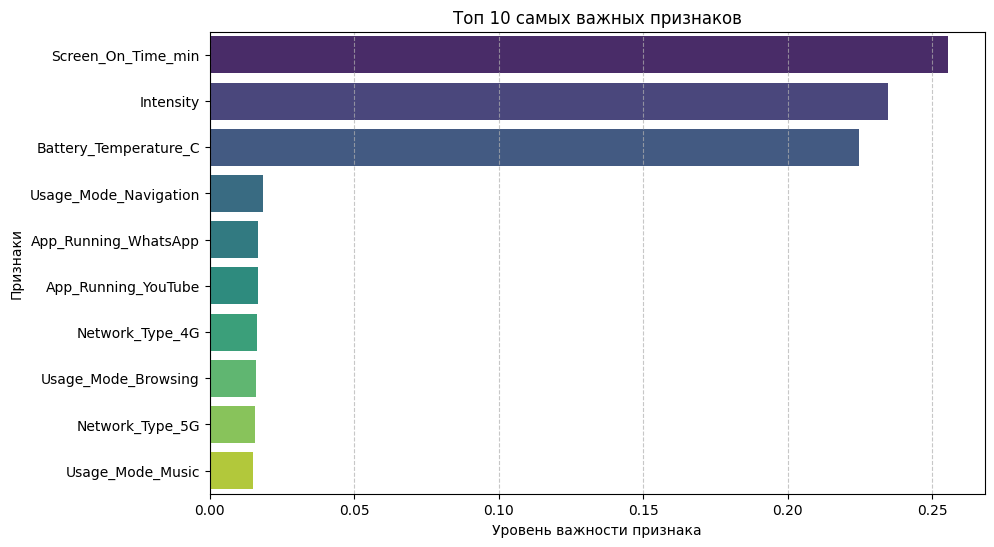

In [144]:
rf1 = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf1.fit(X_train_f, y_train)

importance_df = pd.DataFrame({
    'Feature': X_train_f.columns,
    'Importance': rf1.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=importance_df.head(10),
    hue="Feature",
    palette="viridis",
    legend=False
)

plt.title("Топ 10 самых важных признаков")
plt.xlabel("Уровень важности признака")
plt.ylabel("Признаки")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()